In [1]:
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)


    #Extract ""
    df["neighborhood"]= df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    
    return df

In [4]:
files = glob("../data/raw/buenos-aires-real-estate-*.csv")
files

['../data/raw\\buenos-aires-real-estate-1.csv',
 '../data/raw\\buenos-aires-real-estate-2.csv',
 '../data/raw\\buenos-aires-real-estate-3.csv',
 '../data/raw\\buenos-aires-real-estate-4.csv',
 '../data/raw\\buenos-aires-real-estate-5.csv']

In [5]:
frames = []
for file in files:
    df = wrangle(file)
    frames.append(df)

In [6]:
df = pd.concat(frames, ignore_index=True)
df.shape

(6582, 17)

In [7]:
target = "price_aprox_usd"
features = ["neighborhood"]
y_train = df[target]
X_train = df[features]

In [8]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] *len(y_train)

print("Mean apt price:", y_mean)

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132383.83701458524
Baseline MAE: 44860.10834274133


In [9]:
ohe = OneHotEncoder(use_cat_names=True)
ohe.fit(X_train)
XT_train = ohe.transform(X_train)
print(XT_train.shape)
XT_train.head()

(6582, 57)


,neighborhood_Chacarita,neighborhood_Villa Luro,neighborhood_Caballito,neighborhood_Constitución,neighborhood_Once,neighborhood_Almagro,neighborhood_Palermo,neighborhood_Flores,neighborhood_Belgrano,neighborhood_Liniers,...,neighborhood_Puerto Madero,neighborhood_Agronomía,neighborhood_Monte Castro,neighborhood_Tribunales,neighborhood_Villa Santa Rita,neighborhood_Velez Sarsfield,neighborhood_Villa Soldati,neighborhood_Villa Real,neighborhood_Pompeya,neighborhood_Catalinas
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        #LinearRegression()
        Ridge()
)
model.fit(X_train, y_train)

,steps,"[('onehotencoder', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,['neighborhood']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [12]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 39339.72


In [14]:
X_test = pd.read_csv("../data/raw/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    249409.478261
1    161530.079797
2     98036.930192
3    110675.394444
4    127796.268745
dtype: float64

In [15]:
intercept = model.named_steps["linearregression"].intercept_
coefficients = model.named_steps["linearregression"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 57
[ -1910.75043614   1046.27470672  10324.25164214 -41623.85243614
  -2217.13905402]


In [23]:
intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 57
[-2.89895934e+03 -6.29555347e+00  9.25289088e+03 -4.17487330e+04
 -3.23037446e+03]


In [17]:
feature_names = model.named_steps["onehotencoder"].get_feature_names()
print("features len:", len(feature_names))
print(feature_names[:5])  # First five feature names

features len: 57
['neighborhood_Chacarita' 'neighborhood_Villa Luro'
 'neighborhood_Caballito' 'neighborhood_Constitución' 'neighborhood_Once']


In [18]:
feat_imp = pd.Series(coefficients, index=feature_names)
feat_imp.head()

neighborhood_Chacarita       -1910.750436
neighborhood_Villa Luro       1046.274707
neighborhood_Caballito       10324.251642
neighborhood_Constitución   -41623.852436
neighborhood_Once            -2217.139054
dtype: float64

In [19]:
print(f"price = {intercept.round(2)}")
for f, c in feat_imp.items():
    print(f"+ ({round(c, 2)} * {f})")

price = 117472.02
+ (-1910.75 * neighborhood_Chacarita)
+ (1046.27 * neighborhood_Villa Luro)
+ (10324.25 * neighborhood_Caballito)
+ (-41623.85 * neighborhood_Constitución)
+ (-2217.14 * neighborhood_Once)
+ (3964.48 * neighborhood_Almagro)
+ (47056.22 * neighborhood_Palermo)
+ (-7638.72 * neighborhood_Flores)
+ (48091.9 * neighborhood_Belgrano)
+ (-12974.93 * neighborhood_Liniers)
+ (7345.22 * neighborhood_Villa Crespo)
+ (-9700.16 * neighborhood_San Cristobal)
+ (-7000.99 * neighborhood_Congreso)
+ (15837.8 * neighborhood_Saavedra)
+ (-10169.8 * neighborhood_Balvanera)
+ (-30505.35 * neighborhood_Parque Avellaneda)
+ (74291.64 * neighborhood_Recoleta)
+ (6723.69 * neighborhood_San Telmo)
+ (44058.06 * neighborhood_Nuñez)
+ (56930.11 * neighborhood_Barrio Norte)
+ (-5425.29 * neighborhood_Parque Centenario)
+ (5571.46 * neighborhood_Abasto)
+ (-6993.83 * neighborhood_Centro / Microcentro)
+ (-18554.34 * neighborhood_)
+ (-6178.16 * neighborhood_Paternal)
+ (-20474.63 * neighborhood_M

Ridge Regression
Sometimes,the values for coefficients and the intercept - both positive and negative - are very large. When you see this in a linear model — especially a high-dimensional model — what's happening is that the model is overfitting to the training data and then can't generalize to the test data. Some people call this the curse of dimensionality. ☠️

The way to solve this problem is to use regularization, a group of techniques that prevent overfitting. In this case, we'll change the predictor from LinearRegression to Ridge, which is a linear regressor with an added tool for keeping model coefficients from getting too big.

Here's a good explanation of what a ridge regression is and why it's important:

Text(0.5, 1.0, 'Feature Importance for Apartment Price')

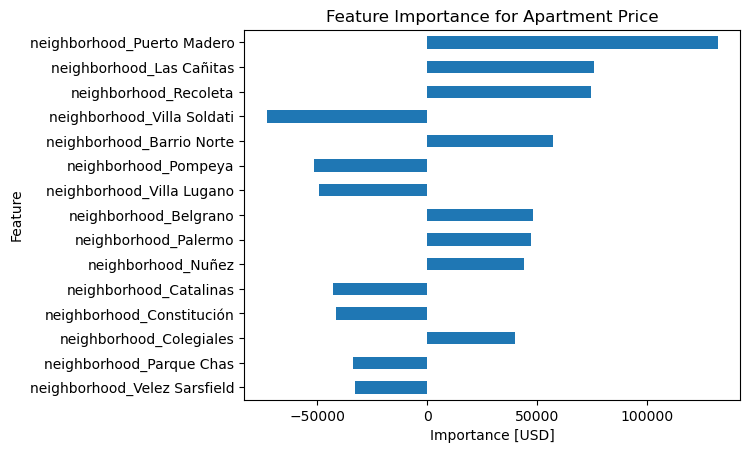

In [20]:
feat_imp.sort_values(key=abs).tail(15).plot(kind="barh")
plt.xlabel("Importance [USD]")
plt.ylabel("Feature")
plt.title("Feature Importance for Apartment Price")